# Garimpo Dataset — Inspection, Patch Extraction & Visualization



In [11]:
# ============================================================
# 0 — CONFIGURATION ET IMPORTS
# ============================================================

from pathlib import Path
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from google.colab import drive


# Connexion à Google Drive
drive.mount("/content/drive")

# Dossier contenant les images TIFF
DOSSIER_ENTREE = Path("/content/drive/MyDrive/garimpo_dataset/")

# Découpage
PATCH_SIZE = 256
STRIDE = 128
SEUIL_VALIDITE = 0.50

# Visualisation
INDEX_IMAGE_TEST = 1
NB_PATCHES_AFFICHER = 3
MAX_DISPLAY = 1600
DPI = 100

# Découverte des images
images = sorted(DOSSIER_ENTREE.glob("*.tif"))

print("Google Drive connecté.")
print(f"Nombre total de fichiers TIFF : {len(images)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connecté.
Nombre total de fichiers TIFF : 102


In [ ]:
# ============================================================
# 1 — INSPECTION DES PREMIÈRES IMAGES TIFF
# ============================================================

print(f"Inspection des {min(5, len(images))} premières images\n")

for i, img in enumerate(images[:5], start=1):
    with rasterio.open(img) as src:
        print(f"Image {i}")
        print(f"  Nom              : {img.name}")
        print(f"  Dimensions       : {src.height} × {src.width}")
        print(f"  Nombre de pixels : {src.height * src.width:,}")
        print(f"  Nombre de bandes : {src.count}")
        print(f"  Résolution       : {src.res[0]} × {src.res[1]} m")
        print(f"  CRS              : {src.crs}")
        print(f"  Bounds           : {src.bounds}")
        print(f"  Type des données : {src.dtypes[0]}")
        print()


Inspection des 5 premières images

Image 1
  Nom              : garimpo_S1_2020-01-01_S2_2020-01-06.tif
  Dimensions       : 9987 × 10003
  Nombre de pixels : 99,899,961
  Nombre de bandes : 6
  Résolution       : 10.0 × 10.0 m
  CRS              : EPSG:32720
  Bounds           : BoundingBox(left=654890.0, bottom=9314130.0, right=754920.0, top=9414000.0)
  Type des données : float32

Image 2
  Nom              : garimpo_S1_2020-02-01_S2_2020-01-31.tif
  Dimensions       : 9987 × 10003
  Nombre de pixels : 99,899,961
  Nombre de bandes : 6
  Résolution       : 10.0 × 10.0 m
  CRS              : EPSG:32720
  Bounds           : BoundingBox(left=654890.0, bottom=9314130.0, right=754920.0, top=9414000.0)
  Type des données : float32

Image 3
  Nom              : garimpo_S1_2020-03-20_S2_2020-03-21.tif
  Dimensions       : 9987 × 10003
  Nombre de pixels : 99,899,961
  Nombre de bandes : 6
  Résolution       : 10.0 × 10.0 m
  CRS              : EPSG:32720
  Bounds           : BoundingBox(lef

Image : garimpo_S1_2020-02-01_S2_2020-01-31.tif
Dimensions originales : 10003 × 9987
Taille affichée : 1200 × 1198


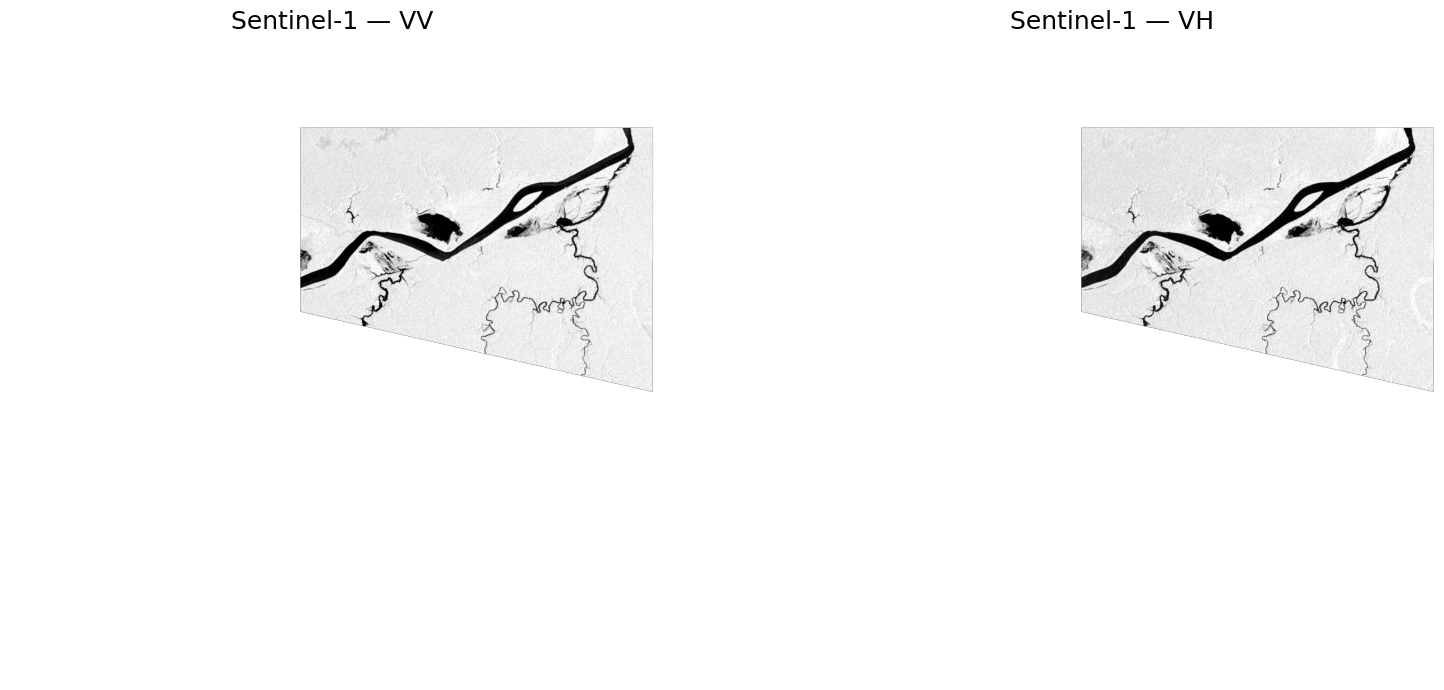

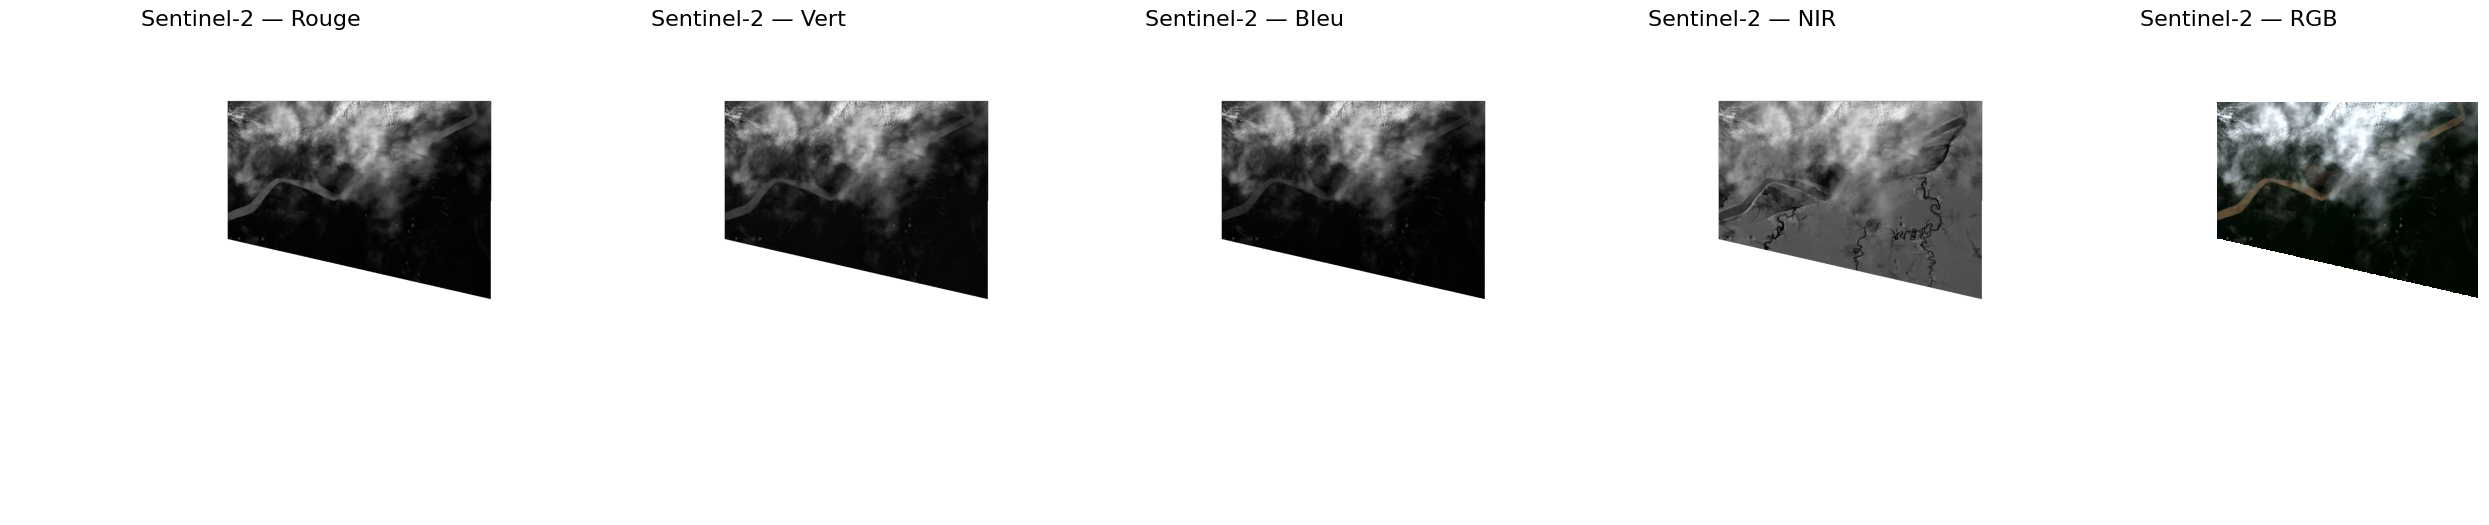

In [ ]:
# ============================================================
# 2 — VISUALISATION DES 6 BANDES DE L'IMAGE TEST
# ============================================================

image_path = images[INDEX_IMAGE_TEST]

with rasterio.open(image_path) as src:
    width, height = src.width, src.height
    max_size = 1200

    scale = min(max_size / width, max_size / height, 1)
    display_width = int(width * scale)
    display_height = int(height * scale)

    image = src.read(
        out_shape=(src.count, display_height, display_width),
        resampling=rasterio.enums.Resampling.bilinear,
    ).astype(np.float32)


def normalize_for_display(band, low=2, high=98):
    """Normalise une bande pour l'affichage avec des percentiles locaux."""
    valid = band[np.isfinite(band)]

    if len(valid) == 0:
        return np.zeros_like(band, dtype=np.float32)

    vmin = np.percentile(valid, low)
    vmax = np.percentile(valid, high)

    if vmax <= vmin:
        return np.zeros_like(band, dtype=np.float32)

    return np.clip((band - vmin) / (vmax - vmin), 0, 1)


def normalize_rgb_for_display(rgb, low=2, high=98):
    """Normalise R, G et B avec une échelle commune pour préserver les proportions."""
    valid = rgb[np.isfinite(rgb)]

    if len(valid) == 0:
        return np.zeros_like(rgb, dtype=np.float32)

    vmin = np.percentile(valid, low)
    vmax = np.percentile(valid, high)

    if vmax <= vmin:
        return np.zeros_like(rgb, dtype=np.float32)

    return np.clip((rgb - vmin) / (vmax - vmin), 0, 1)


VV_display = normalize_for_display(image[0])
VH_display = normalize_for_display(image[1])

RGB_display = np.transpose(
    normalize_rgb_for_display(image[2:5]),
    (1, 2, 0),
)

NIR_display = normalize_for_display(image[5])

print(f"Image : {image_path.name}")
print(f"Dimensions originales : {width} × {height}")
print(f"Taille affichée : {display_width} × {display_height}")


# Sentinel-1
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, band, title in zip(
    axes,
    [VV_display, VH_display],
    ["Sentinel-1 — VV", "Sentinel-1 — VH"],
):
    ax.imshow(band, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=18)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Sentinel-2
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

band_titles = [
    "Sentinel-2 — Rouge",
    "Sentinel-2 — Vert",
    "Sentinel-2 — Bleu",
    "Sentinel-2 — NIR",
    "Sentinel-2 — RGB",
]

for ax, band, title in zip(
    axes,
    [image[2], image[3], image[4], image[5], RGB_display],
    band_titles,
):
    ax.imshow(band, cmap="gray" if band.ndim == 2 else None)
    ax.set_title(title, fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 3 — PARAMÈTRES DU DÉCOUPAGE
# ============================================================

print("Paramètres du découpage")
print("-----------------------")
print(f"Taille du patch       : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Stride                : {STRIDE}")
print(f"Recouvrement          : {PATCH_SIZE - STRIDE} pixels")
print(f"Validité minimale     : {SEUIL_VALIDITE * 100:.0f} %")
print(f"Nombre de patches     : {NB_PATCHES_AFFICHER}")


Paramètres du découpage
-----------------------
Taille du patch       : 256 × 256
Stride                : 128
Recouvrement          : 128 pixels
Validité minimale     : 50 %
Nombre de patches     : 3


In [15]:
# ============================================================
# 4 — LECTURE DE L'IMAGE TEST ET CRÉATION DU MASQUE
# ============================================================

image_path = images[INDEX_IMAGE_TEST]

with rasterio.open(image_path) as src:
    H, W = src.height, src.width
    data = src.read().astype(np.float32)

print("=" * 70)
print("IMAGE TEST")
print("=" * 70)
print(f"Nom        : {image_path.name}")
print(f"Dimensions : {W} × {H}")
print(f"Bandes     : {data.shape[0]}")


# Un pixel est valide si :
# 1. les 6 bandes possèdent des valeurs numériques ;
# 2. les 6 bandes ne sont pas simultanément égales à zéro.
valid_mask = (
    np.all(np.isfinite(data), axis=0)
    & ~np.all(data == 0, axis=0)
)

nombre_pixels = H * W
nombre_valides = np.count_nonzero(valid_mask)

print("\nZONE VALIDE")
print("-----------")
print(f"Pixels totaux  : {nombre_pixels:,}")
print(f"Pixels valides : {nombre_valides:,}")
print(f"Surface valide : {nombre_valides / nombre_pixels * 100:.2f} %")


IMAGE TEST
Nom        : garimpo_S1_2020-02-01_S2_2020-01-31.tif
Dimensions : 10003 × 9987
Bandes     : 6

ZONE VALIDE
-----------
Pixels totaux  : 99,899,961
Pixels valides : 19,183,202
Surface valide : 19.20 %


In [16]:
# ============================================================
# 5 — CALCUL DES PATCHES VALIDES
# ============================================================

patches_valides = []

for row in range(0, H - PATCH_SIZE + 1, STRIDE):
    for col in range(0, W - PATCH_SIZE + 1, STRIDE):
        patch_mask = valid_mask[
            row:row + PATCH_SIZE,
            col:col + PATCH_SIZE,
        ]

        validite = patch_mask.mean()

        if validite >= SEUIL_VALIDITE:
            patches_valides.append({
                "row": row,
                "col": col,
                "validite": validite,
            })


nombre_lignes = ((H - PATCH_SIZE) // STRIDE) + 1
nombre_colonnes = ((W - PATCH_SIZE) // STRIDE) + 1
nombre_total = nombre_lignes * nombre_colonnes

print("=" * 70)
print("RÉSULTAT DU DÉCOUPAGE")
print("=" * 70)
print(f"Positions possibles : {nombre_total:,}")
print(f"Patches valides     : {len(patches_valides):,}")
print(f"Patches rejetés     : {nombre_total - len(patches_valides):,}")
print(f"Patches conservés   : {len(patches_valides) / nombre_total * 100:.2f} %")


RÉSULTAT DU DÉCOUPAGE
Positions possibles : 5,929
Patches valides     : 1,164
Patches rejetés     : 4,765
Patches conservés   : 19.63 %


In [ ]:
# ============================================================
# 6 — NORMALISATION GLOBALE
# Les mêmes limites sont utilisées pour l'image complète
# et pour tous les patches.
# ============================================================

def get_global_limits(band, low=2, high=98):
    """Calcule les limites de normalisation sur les valeurs valides."""
    valid = band[np.isfinite(band) & (band != 0)]

    if len(valid) == 0:
        return 0.0, 1.0

    vmin = np.percentile(valid, low)
    vmax = np.percentile(valid, high)

    if vmax <= vmin:
        vmax = vmin + 1e-6

    return vmin, vmax


def apply_global_normalization(band, vmin, vmax):
    """Applique des limites de normalisation déjà calculées."""
    normalized = (band - vmin) / (vmax - vmin)
    return np.clip(normalized, 0, 1).astype(np.float32)


VV_MIN, VV_MAX = get_global_limits(data[0])
VH_MIN, VH_MAX = get_global_limits(data[1])

rgb_data = data[2:5]
valid_rgb = rgb_data[np.isfinite(rgb_data) & (rgb_data != 0)]

RGB_MIN = np.percentile(valid_rgb, 2)
RGB_MAX = np.percentile(valid_rgb, 98)

if RGB_MAX <= RGB_MIN:
    RGB_MAX = RGB_MIN + 1e-6

print("=" * 70)
print("NORMALISATION GLOBALE")
print("=" * 70)
print(f"VV  : {VV_MIN:.4f} → {VV_MAX:.4f}")
print(f"VH  : {VH_MIN:.4f} → {VH_MAX:.4f}")
print(f"RGB : {RGB_MIN:.4f} → {RGB_MAX:.4f}")


NORMALISATION GLOBALE
VV  : -24.4159 → -4.0939
VH  : -29.8674 → -10.3487
RGB : 177.0000 → 5572.0000

Ces mêmes limites seront utilisées pour l'image complète et les patches.


PATCHES SÉLECTIONNÉS
P1 | row = 3456 | col = 5888 | validité = 100.0% | taille = 256×256
P2 | row = 3328 | col = 6912 | validité = 100.0% | taille = 256×256
P3 | row = 3584 | col = 4992 | validité = 100.0% | taille = 256×256


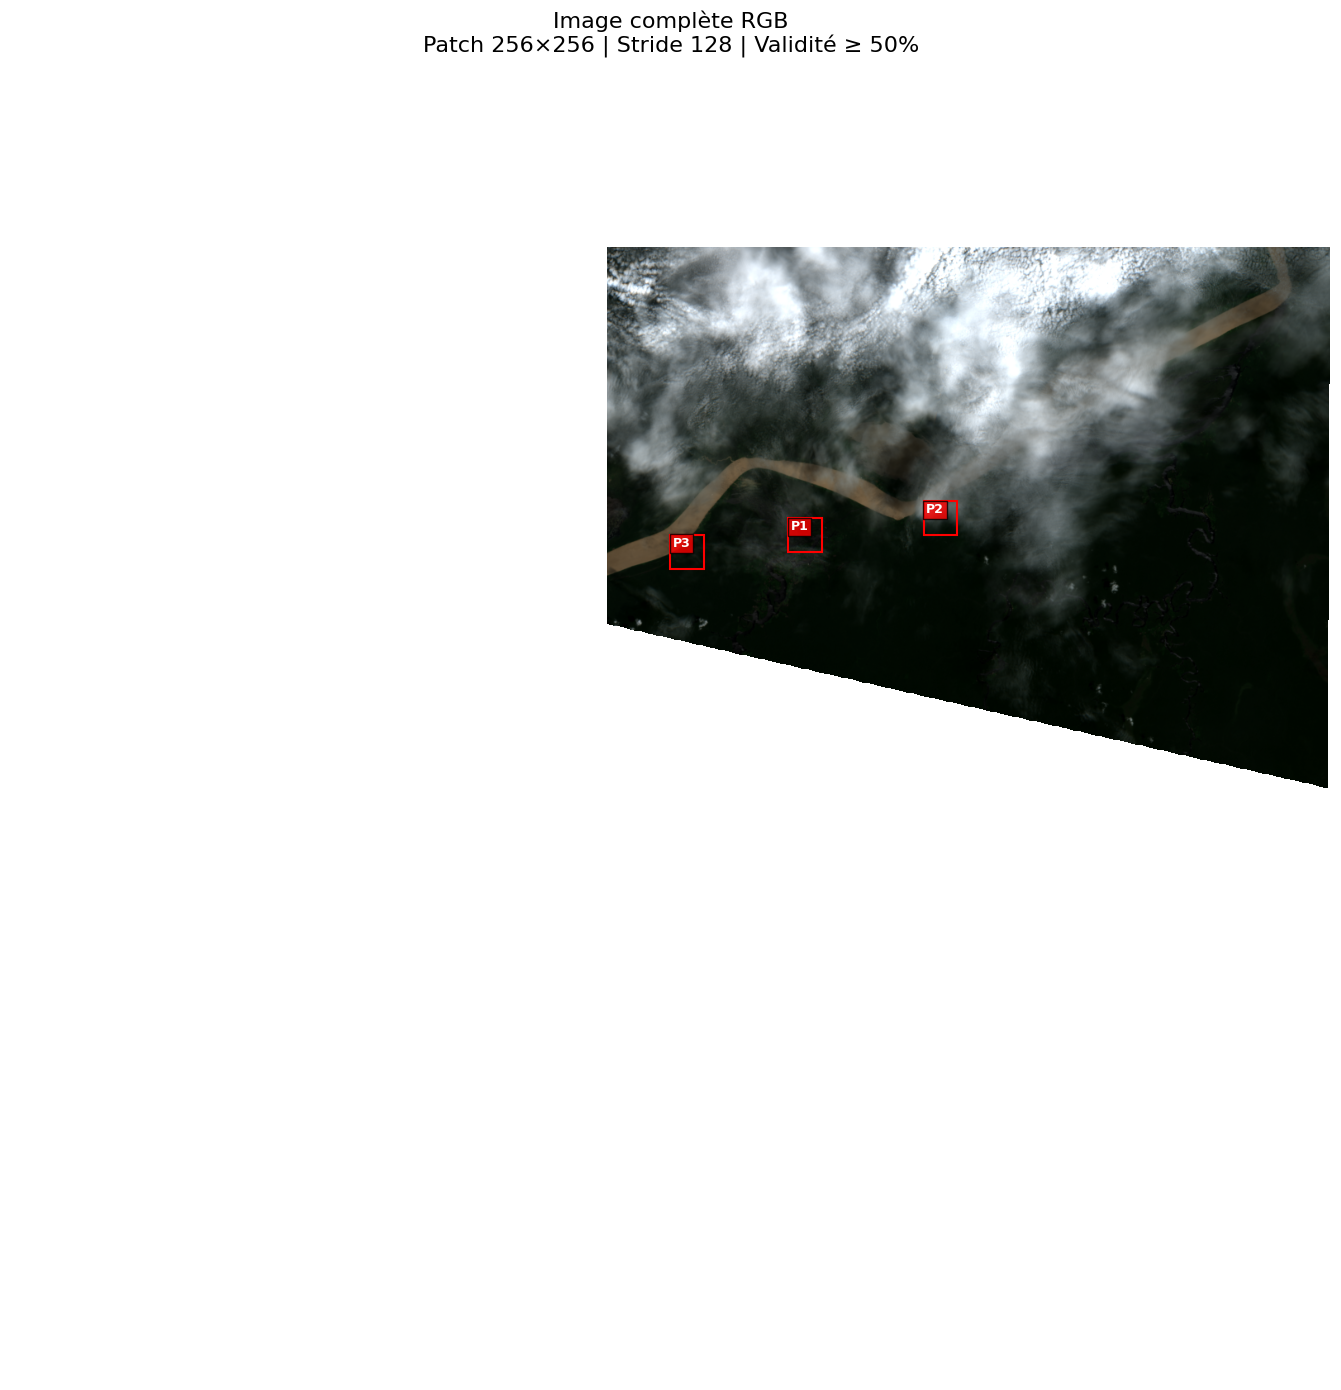

In [22]:
# ============================================================
# 7 — VISUALISATION DE L'IMAGE COMPLÈTE AVEC PATCHES
# ============================================================

nombre_a_afficher = min(NB_PATCHES_AFFICHER, len(patches_valides))

# Sélection aléatoire conservée volontairement sans seed,
# comme dans le notebook original.
patches_selectionnes = random.sample(
    patches_valides,
    nombre_a_afficher,
)

print("=" * 70)
print("PATCHES SÉLECTIONNÉS")
print("=" * 70)

for numero, patch in enumerate(patches_selectionnes, start=1):
    print(
        f"P{numero} | "
        f"row = {patch['row']} | "
        f"col = {patch['col']} | "
        f"validité = {patch['validite'] * 100:.1f}% | "
        f"taille = {PATCH_SIZE}×{PATCH_SIZE}"
    )


scale = min(MAX_DISPLAY / W, MAX_DISPLAY / H, 1)
display_width = int(W * scale)
display_height = int(H * scale)

with rasterio.open(image_path) as src:
    rgb_display = src.read(
        [3, 4, 5],
        out_shape=(3, display_height, display_width),
        resampling=rasterio.enums.Resampling.bilinear,
    ).astype(np.float32)


RGB_display = np.empty_like(rgb_display, dtype=np.float32)

for channel in range(3):
    RGB_display[channel] = apply_global_normalization(
        rgb_display[channel],
        RGB_MIN,
        RGB_MAX,
    )

RGB_display = np.transpose(RGB_display, (1, 2, 0))


fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(RGB_display)

for numero, patch in enumerate(patches_selectionnes, start=1):
    row, col = patch["row"], patch["col"]

    x = col * scale
    y = row * scale
    largeur = PATCH_SIZE * scale
    hauteur = PATCH_SIZE * scale

    rectangle = mpatches.Rectangle(
        (x, y),
        largeur,
        hauteur,
        linewidth=1.5,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rectangle)

    ax.text(
        x + 3,
        y + 15,
        f"P{numero}",
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="red", alpha=0.8, pad=2),
    )

ax.set_title(
    f"Image complète RGB\n"
    f"Patch {PATCH_SIZE}×{PATCH_SIZE} | "
    f"Stride {STRIDE} | "
    f"Validité ≥ {SEUIL_VALIDITE * 100:.0f}%",
    fontsize=16,
)
ax.axis("off")

plt.tight_layout()
plt.show()

del rgb_display, RGB_display


P1 : row=3456, col=5888, validité=100.0%, dimensions=256×256


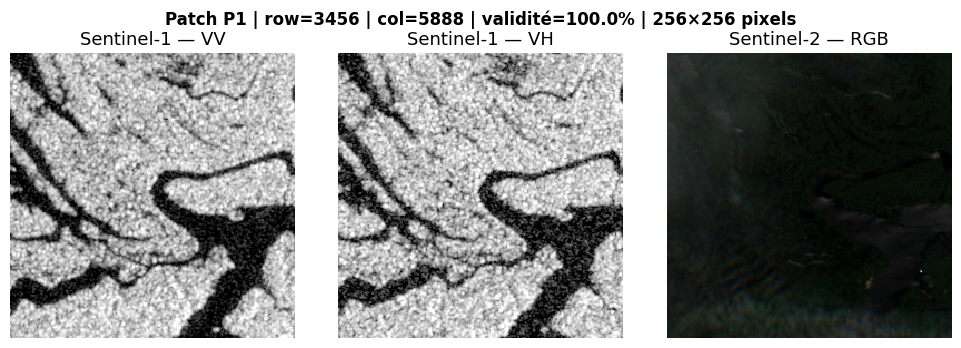

P2 : row=3328, col=6912, validité=100.0%, dimensions=256×256


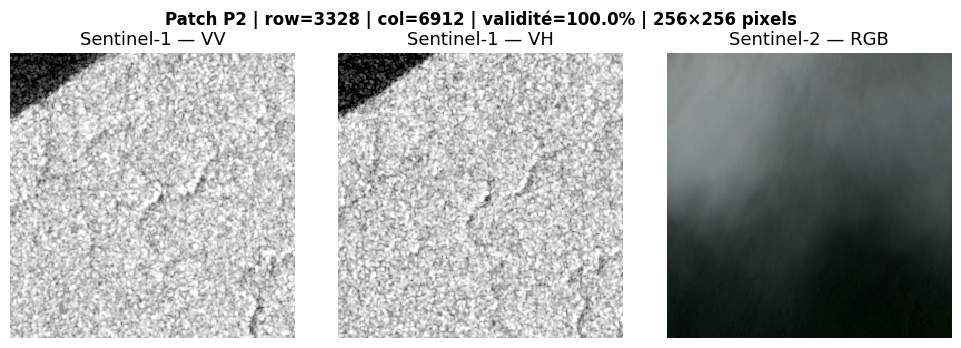

P3 : row=3584, col=4992, validité=100.0%, dimensions=256×256


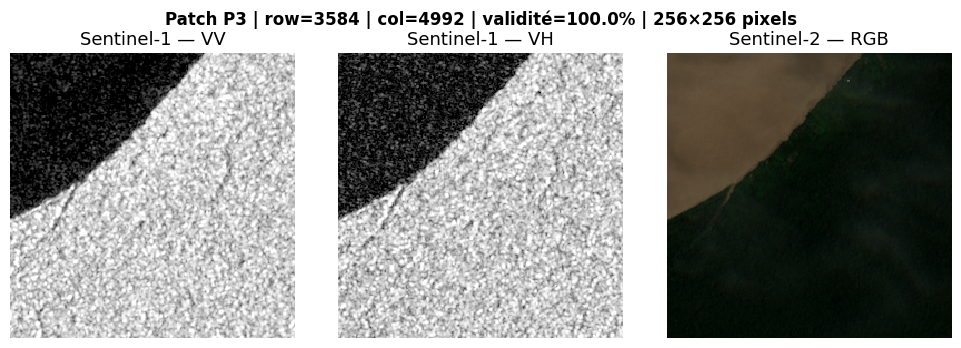

In [23]:
# ============================================================
# 8 — AFFICHAGE DES PATCHES : VV | VH | RGB
# ============================================================

with rasterio.open(image_path) as src:
    for numero, patch in enumerate(
        patches_selectionnes[:NB_PATCHES_AFFICHER],
        start=1,
    ):
        row = patch["row"]
        col = patch["col"]
        validite = patch["validite"]

        window = rasterio.windows.Window(
            col,
            row,
            PATCH_SIZE,
            PATCH_SIZE,
        )

        patch_data = src.read(
            [1, 2, 3, 4, 5],
            window=window,
        ).astype(np.float32)

        print(
            f"P{numero} : "
            f"row={row}, "
            f"col={col}, "
            f"validité={validite * 100:.1f}%, "
            f"dimensions={patch_data.shape[1]}×{patch_data.shape[2]}"
        )

        patch_VV = apply_global_normalization(
            patch_data[0], VV_MIN, VV_MAX
        )
        patch_VH = apply_global_normalization(
            patch_data[1], VH_MIN, VH_MAX
        )

        patch_RGB = np.empty(
            (PATCH_SIZE, PATCH_SIZE, 3),
            dtype=np.float32,
        )

        for channel in range(3):
            patch_RGB[:, :, channel] = apply_global_normalization(
                patch_data[channel + 2],
                RGB_MIN,
                RGB_MAX,
            )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(10, 3.5),
            dpi=DPI,
        )

        for ax, band, title in zip(
            axes,
            [patch_VV, patch_VH, patch_RGB],
            ["Sentinel-1 — VV", "Sentinel-1 — VH", "Sentinel-2 — RGB"],
        ):
            ax.imshow(
                band,
                cmap="gray" if band.ndim == 2 else None,
                vmin=0 if band.ndim == 2 else None,
                vmax=1 if band.ndim == 2 else None,
                interpolation="none",
            )
            ax.set_title(title, fontsize=13)
            ax.axis("off")

        fig.suptitle(
            f"Patch P{numero} | "
            f"row={row} | "
            f"col={col} | "
            f"validité={validite * 100:.1f}% | "
            f"{PATCH_SIZE}×{PATCH_SIZE} pixels",
            fontsize=12,
            fontweight="bold",
        )

        plt.tight_layout()
        plt.show()

        del patch_data, patch_VV, patch_VH, patch_RGB
